<a href="https://colab.research.google.com/github/alinamanbek/1/blob/alina/1_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading the dataset

Data wrangling for missing variables.

Data transformation.

Data visualization

In [ ]:
# Import necessary libraries and suppress warnings
import warnings
warnings.simplefilter(action='ignore')

import pandas as pd
import numpy as np
import random

# For sparse matrices and nearest neighbors (if needed later)
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(style="whitegrid")

# Scaling and preprocessing libraries
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Feature selection libraries
from sklearn.feature_selection import RFE, chi2, SelectKBest

# Classifiers and models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Datasets and sampling techniques
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Model selection and evaluation
from sklearn.model_selection import train_test_split

# Statistical functions
from scipy.stats import skew, pearsonr


import numpy as np
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
df_red = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv", delimiter=";")
df_white = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv", delimiter=";")


In [ ]:
display(df_red.head(3))
display(df_white.head(3))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6


In [ ]:
# Overview of red wine dataset
print("RED")
display(df_red.dtypes)
print("WHITE")
display(df_white.dtypes)

RED


,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


WHITE


,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [ ]:
print("RED")
display(df_white.info())
print("WHITE")
display(df_red.info())

RED
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


None

WHITE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


None

In [ ]:
s=df_red["quality"].unique()
display(len(s))

6

In [ ]:
print("Sample rows from Red/White Wine Dataset:\n")
print("RED\n")
display(df_red.iloc[100:110:2])
print("\nWHITE\n")
display(df_white.iloc[100:110:2])

Sample rows from Red/White Wine Dataset:

RED



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
100,8.3,0.610,0.30,2.1,0.084,11.0,50.0,0.9972,3.40,0.61,10.2,6
102,8.1,0.545,0.18,1.9,0.080,13.0,35.0,0.9972,3.30,0.59,9.0,6
104,7.2,0.490,0.24,2.2,0.070,5.0,36.0,0.9960,3.33,0.48,9.4,5
106,7.8,0.410,0.68,1.7,0.467,18.0,69.0,0.9973,3.08,1.31,9.3,5
108,8.0,0.330,0.53,2.5,0.091,18.0,80.0,0.9976,3.37,0.80,9.6,6



WHITE



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
100,7.4,0.25,0.37,13.5,0.060,52.0,192.0,0.9975,3.00,0.44,9.1,5
102,6.0,0.21,0.24,12.1,0.050,55.0,164.0,0.9970,3.34,0.39,9.4,5
104,7.4,0.25,0.37,13.5,0.060,52.0,192.0,0.9975,3.00,0.44,9.1,5
106,7.1,0.12,0.32,9.6,0.054,64.0,162.0,0.9962,3.40,0.41,9.4,5
108,7.1,0.23,0.35,16.5,0.040,60.0,171.0,0.9990,3.16,0.59,9.1,6


In [ ]:
df_red["alcohol"].unique()

array([ 9.4       ,  9.8       , 10.        ,  9.5       , 10.5       ,
        9.2       ,  9.9       ,  9.1       ,  9.3       ,  9.        ,
        9.7       , 10.1       , 10.6       ,  9.6       , 10.8       ,
       10.3       , 13.1       , 10.2       , 10.9       , 10.7       ,
       12.9       , 10.4       , 13.        , 14.        , 11.5       ,
       11.4       , 12.4       , 11.        , 12.2       , 12.8       ,
       12.6       , 12.5       , 11.7       , 11.3       , 12.3       ,
       12.        , 11.9       , 11.8       ,  8.7       , 13.3       ,
       11.2       , 11.6       , 11.1       , 13.4       , 12.1       ,
        8.4       , 12.7       , 14.9       , 13.2       , 13.6       ,
       13.5       , 10.03333333,  9.55      ,  8.5       , 11.06666667,
        9.56666667, 10.55      ,  8.8       , 13.56666667, 11.95      ,
        9.95      ,  9.23333333,  9.25      ,  9.05      , 10.75      ])

In [ ]:
print("Statistic from Red/White Wine Dataset:\n")
print("RED\n")
display(df_red.describe())
print("\nWHITE\n")
display(df_white.describe())

Statistic from Red/White Wine Dataset:

RED



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000



WHITE



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


Красное вино более кислотное, плотное, солёное и содержит меньше сахара и серы.


Белое вино слаще, менее кислое, содержит больше SO₂ (консервантов) и более лёгкое.

Белое вино имеет большую вариативность по сахару и содержанию серы.

### Cell 4: Visual Analysis of Red Wine

<Figure size 800x600 with 0 Axes>

<Figure size 640x480 with 0 Axes>

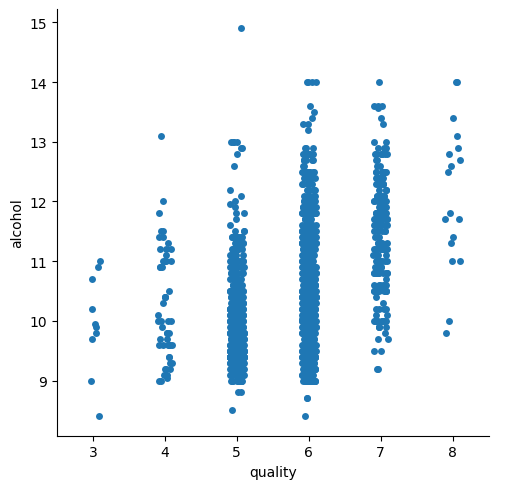

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

plt.figure()
sns.catplot(x="quality", data=df_red, y="alcohol")
plt.show()


<Figure size 800x600 with 0 Axes>

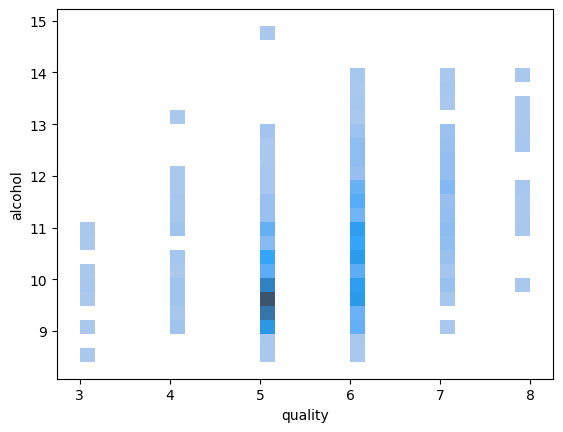

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

plt.figure()
sns.histplot(x="quality", data=df_red, y="alcohol")
plt.show()


import seaborn as sns
import pandas as pd

# Example dataset: Customer data
data = {
    'Age': [25, 30, 35, 40, 45],
    'Income': [40000, 50000, 60000, 70000, 80000],
    'Spending': [2000, 2500, 3000, 3500, 4000]
}

df = pd.DataFrame(data)

# Pairplot to visualize relationships between all variables
sns.pairplot(df)
plt.show()


<Figure size 800x600 with 0 Axes>

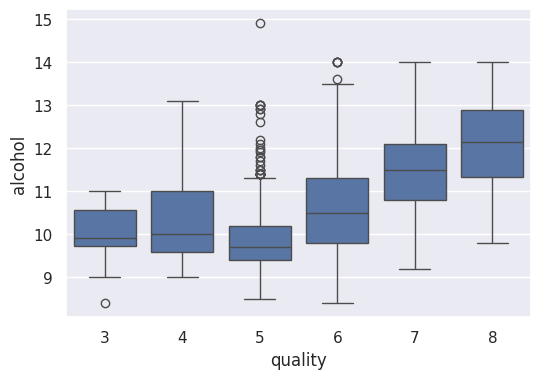

In [ ]:
plt.figure(figsize=(8, 6))

plt.figure()
sns.boxplot(x="quality", data=df_red, y="alcohol"),#showfliers=False without outliers
plt.show()



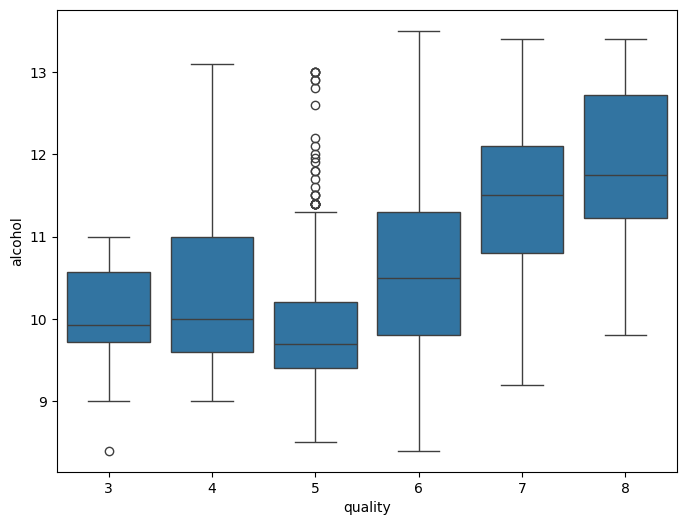

In [ ]:


# Calculate the IQR for the 'alcohol' column
Q1 = df_red['alcohol'].quantile(0.25)
Q3 = df_red['alcohol'].quantile(0.75)
IQR = Q3 - Q1

# Define the range to exclude outliers (usually 1.5*IQR below Q1 or above Q3)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the data to remove outliers
filtered_df = df_red[(df_red['alcohol'] >= lower_bound) & (df_red['alcohol'] <= upper_bound)]

# Plot the boxplot without outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x="quality", y="alcohol", data=filtered_df)
plt.show()


cumulative destribution

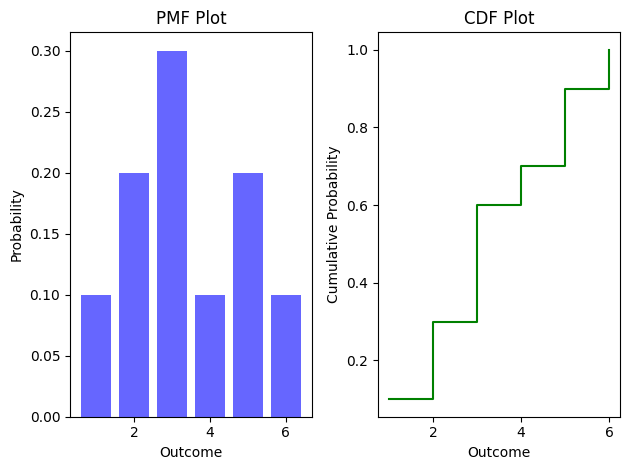

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example data: Discrete outcomes
outcomes = [1, 2, 3, 4, 5, 6]
probabilities = [0.1, 0.2, 0.3, 0.1, 0.2, 0.1]

# Calculate CDF
cdf = np.cumsum(probabilities)

# Plot PMF
plt.subplot(1, 2, 1)
plt.bar(outcomes, probabilities, color='blue', alpha=0.6, label='PMF')
plt.title('PMF Plot')
plt.xlabel('Outcome')
plt.ylabel('Probability')

# Plot CDF
plt.subplot(1, 2, 2)
plt.step(outcomes, cdf, color='green', label='CDF', where='post')
plt.title('CDF Plot')
plt.xlabel('Outcome')
plt.ylabel('Cumulative Probability')

plt.tight_layout()
plt.show()


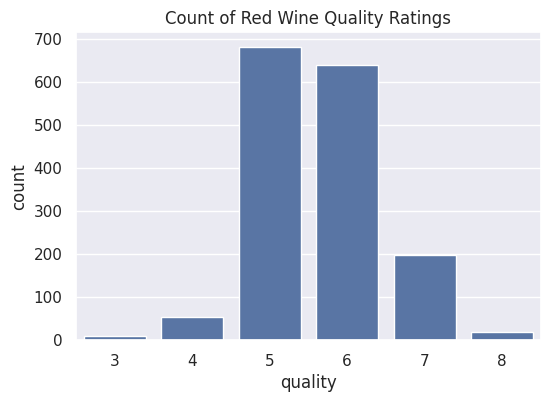

In [ ]:
sns.set(rc={'figure.figsize': (6, 4)})

# Count plot for quality
plt.figure()
sns.countplot(x=df_red['quality'])
plt.title("Count of Red Wine Quality Ratings")
plt.show()

<Figure size 600x400 with 0 Axes>

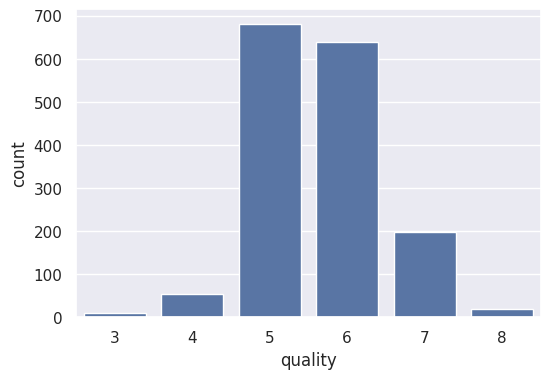

In [ ]:
#countplot
plt.figure(figsize=(6,4))

plt.figure()
sns.countplot(x=df_red["quality"])
plt.show()


multivariet analaysis

In [ ]:
#scatter plot
#pair plot
#corr
#headmap

plt.figure(figsize=(6,4))

plt.figure()
sns.scatterplot(data=df_red, x="quality", y="alcohol")
plt.show()

TypeError: 'module' object is not callable

In [ ]:
df_red.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

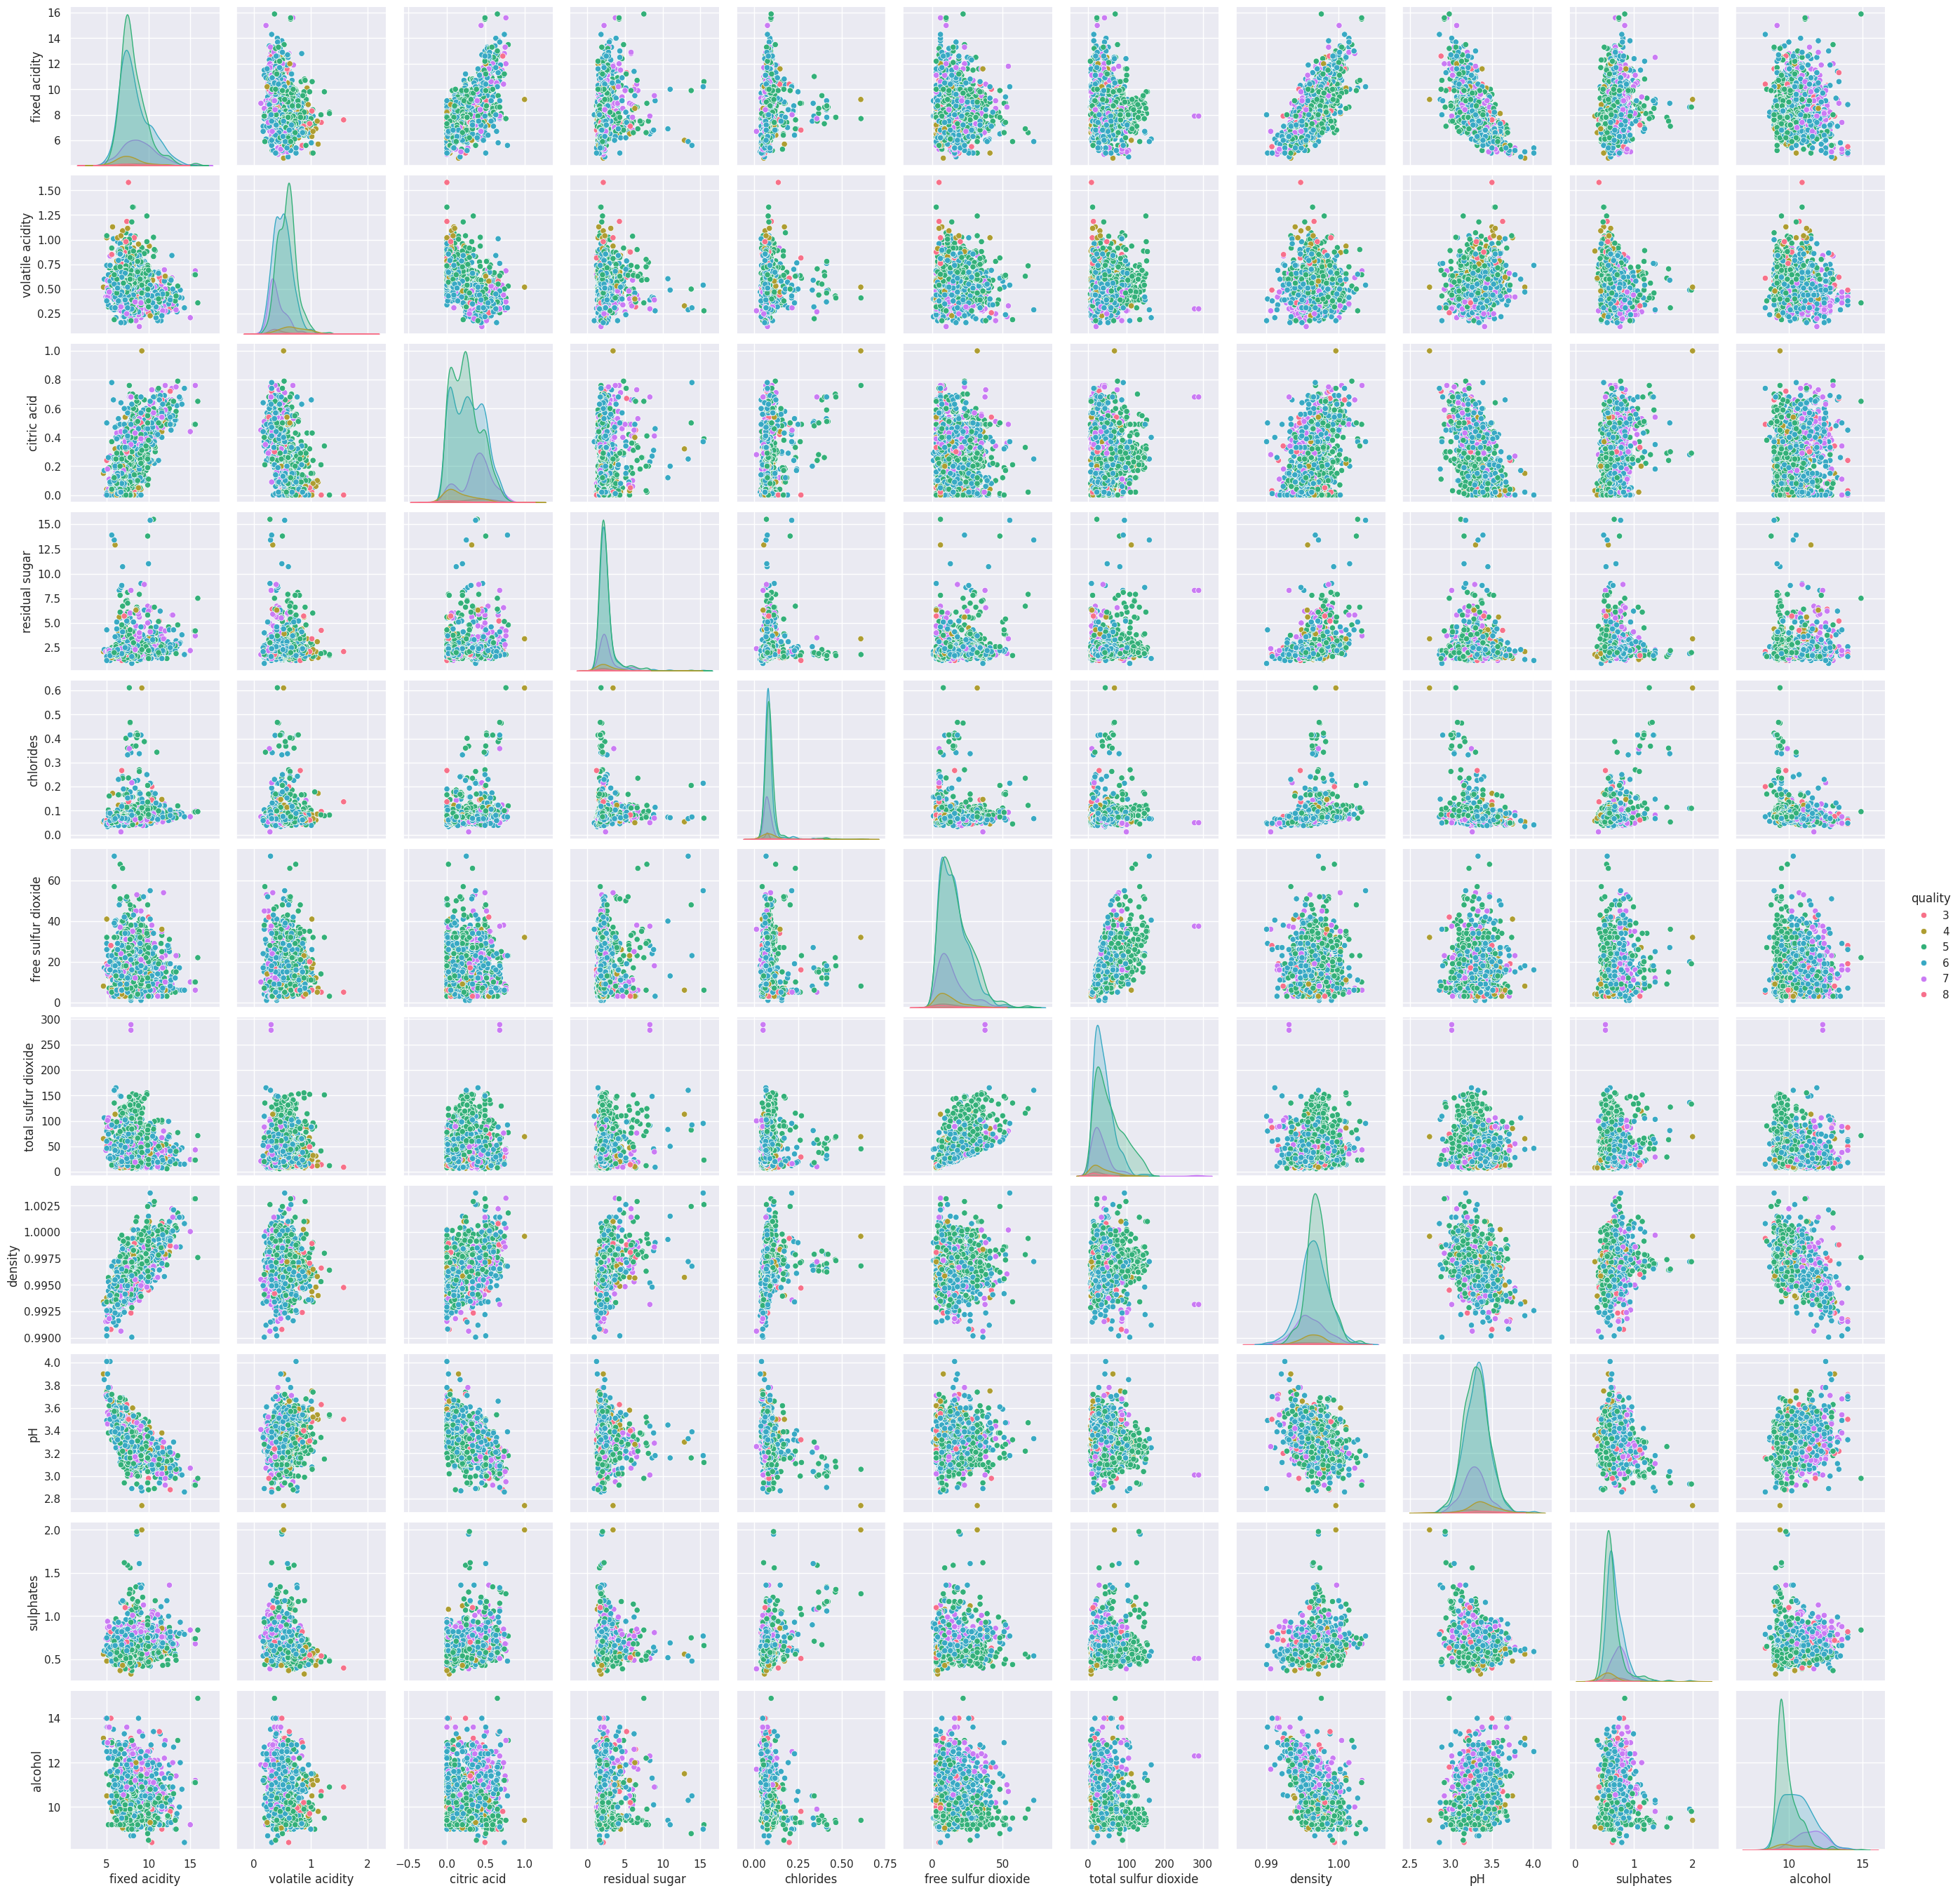

In [ ]:
#pairplot
sns.pairplot(data=df_red, hue="quality", palette="husl")
plt.show()

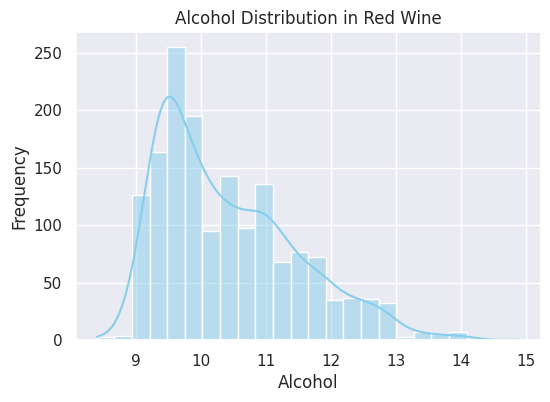

In [ ]:
# Distribution plot for alcohol
plt.figure()
sns.histplot(df_red['alcohol'], kde=True, color='skyblue')
plt.title("Alcohol Distribution in Red Wine")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.show()

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

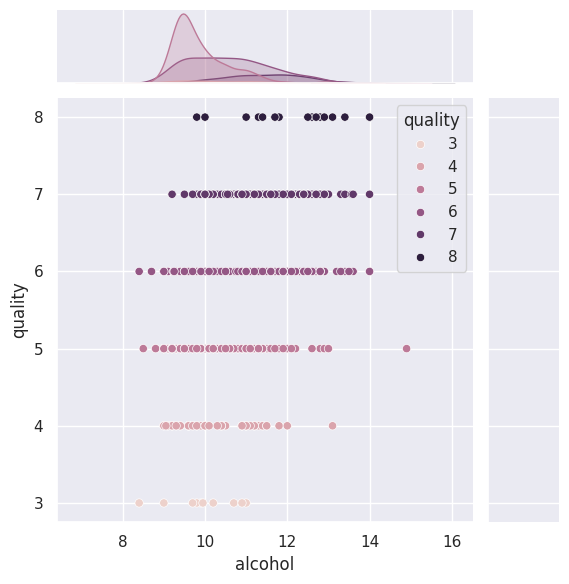

In [ ]:
plt.figure(figsize=(6,4))

plt.figure()
sns.jointplot(data=df_red, x="alcohol", y="quality", kind="scatter", hue="quality")  # kind=> scatter,
plt.show()

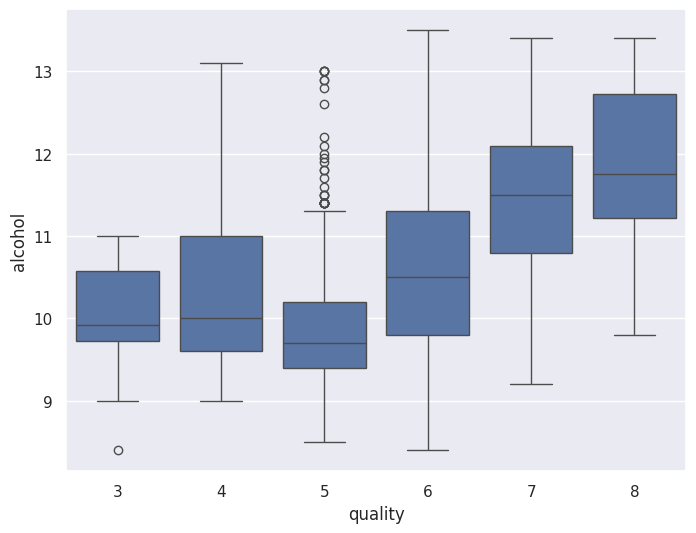

In [ ]:


# Calculate the IQR for the 'alcohol' column
Q1 =df_red["alcohol"].quantile(0.25)
Q3 =df_red["alcohol"].quantile(0.75)
IQR = Q3 - Q1

# Define the range to exclude outliers (usually 1.5*IQR below Q1 or above Q3)
lower_bound = Q1- 1.5*IQR
upper_bound = Q3 + 1.5*IQR

# Filter the data to remove outliers
filtered_df = df_red[(df_red["alcohol"] <= upper_bound ) & (df_red["alcohol"] >= lower_bound)]

# Plot the boxplot without outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x="quality", y="alcohol", data=filtered_df)
plt.show()


In [ ]:
#Percentile
#basic
import numpy as np

#data = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

# Calculate 25th, 50th (median), and 75th percentiles
p25 = np.percentile(df_red["alcohol"], 25)  # First quartile (Q1)
p50 = np.percentile(df_red["alcohol"], 50)  # Median (Q2)
p75 = np.percentile(df_red["alcohol"], 75)  # Third quartile (Q3)

print(f"25th Percentile (Q1): {p25}")
print(f"50th Percentile (Median, Q2): {p50}")
print(f"75th Percentile (Q3): {p75}")



25th Percentile (Q1): 9.5
50th Percentile (Median, Q2): 10.2
75th Percentile (Q3): 11.1


In [ ]:
percentiles = np.percentile(df_red["alcohol"], [10, 25, 50, 75, 90])
print(percentiles)


[ 9.3  9.5 10.2 11.1 12. ]


In [ ]:
#GESD in Python
import numpy as np
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Example data
data = np.array([10, 12, 13, 15, 100, 14, 16, 17, 18, 20])  # 100 is an outlier

# Step 1: Calculate mean & standard deviation
mean_val = np.mean(data)
std_dev = np.std(data)

# Step 2: Calculate R values (deviation from mean)
R_values = np.abs(data - mean_val) / std_dev

# Step 3: Find the most extreme value
max_index = np.argmax(R_values)
outlier = data[max_index]

print(f"Possible Outlier: {outlier}")
print(f"R-value: {R_values[max_index]}")


Possible Outlier: 100
R-value: 2.9821671945419856


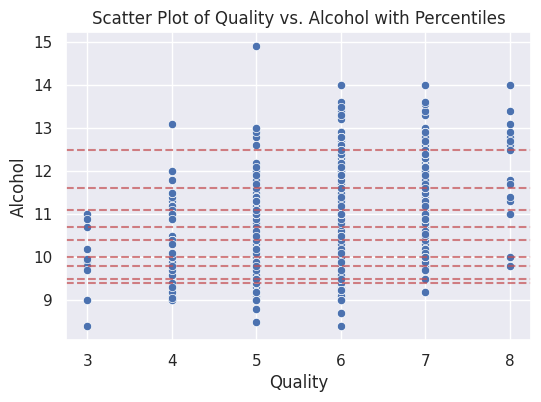

In [ ]:
#percentiles for "alcohol"
percentiles = np.percentile(df_red["alcohol"], [ 15, 25, 35, 45,55,65,75,85,95])

# Create scatter plot
plt.figure(figsize=(6, 4))

sns.scatterplot(data=df_red, x="quality", y="alcohol")

# Add horizontal lines for percentiles
for p in percentiles:
    plt.axhline(p, color='r', linestyle='--', alpha=0.7, label=f'Percentile: {p:.2f}')

# Labels and title
plt.xlabel("Quality")
plt.ylabel("Alcohol")
plt.title("Scatter Plot of Quality vs. Alcohol with Percentiles")

plt.show()


In [ ]:

print("Percentiles:", percentiles)


Percentiles: [ 9.4  9.5  9.8 10.  10.4 10.7 11.1 11.6 12.5]


correlation
Covariance
▪ In order to compare two variables, they must have the same
unit of measurement
▪ alternatively, they must be normalised
▪ Pearson
▪ Solves the problem of normalization
▪ Only detect linear correlation
▪ Spearman

In [ ]:
plt.figure(figsize=(6,5))
corry=df_white.corr()
sns.heatmap(corry, annot=True,cmp="coolwarm")
plt.show


TypeError: 'module' object is not callable

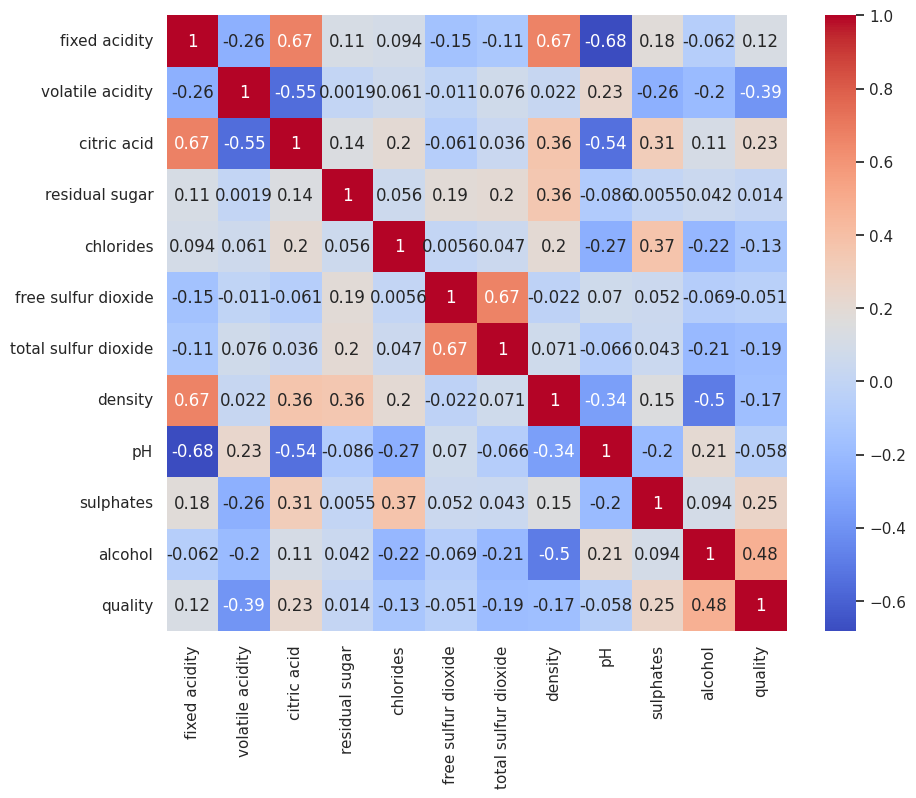

In [ ]:

plt.figure(figsize=(10,8))
corr = df_red.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

Data transformation categorical variables

In [ ]:
import pandas as pd

# Example data
data = {'Color': ['Red', 'Blue', 'Green', 'Red', 'Blue']}

# Create DataFrame
df = pd.DataFrame(data)

# Apply One-Hot Encoding using pandas get_dummies
encoded_df = pd.get_dummies(df, columns=['Color'])

print(encoded_df)


   Color_Blue  Color_Green  Color_Red
0       False        False       True
1        True        False      False
2       False         True      False
3       False        False       True
4        True        False      False


In [ ]:
#Dummy Coding:
dummy_df = pd.get_dummies(df, columns=['Color'], drop_first=True)

print(dummy_df)

   Color_Green  Color_Red
0        False       True
1        False      False
2         True      False
3        False       True
4        False      False


In [ ]:
#Effect
df['Color_Blue'] = df['Color'].apply(lambda x: 1 if x == 'Blue' else (-1 if x != 'Red' else 0))
df['Color_Green'] = df['Color'].apply(lambda x: 1 if x == 'Green' else (-1 if x != 'Red' else 0))
print(df)

   Color  Color_Blue  Color_Green
0    Red           0            0
1   Blue           1           -1
2  Green          -1            1
3    Red           0            0
4   Blue           1           -1


Data Visualization
* heatmap
* t-sne
* worldcloud
* PCA

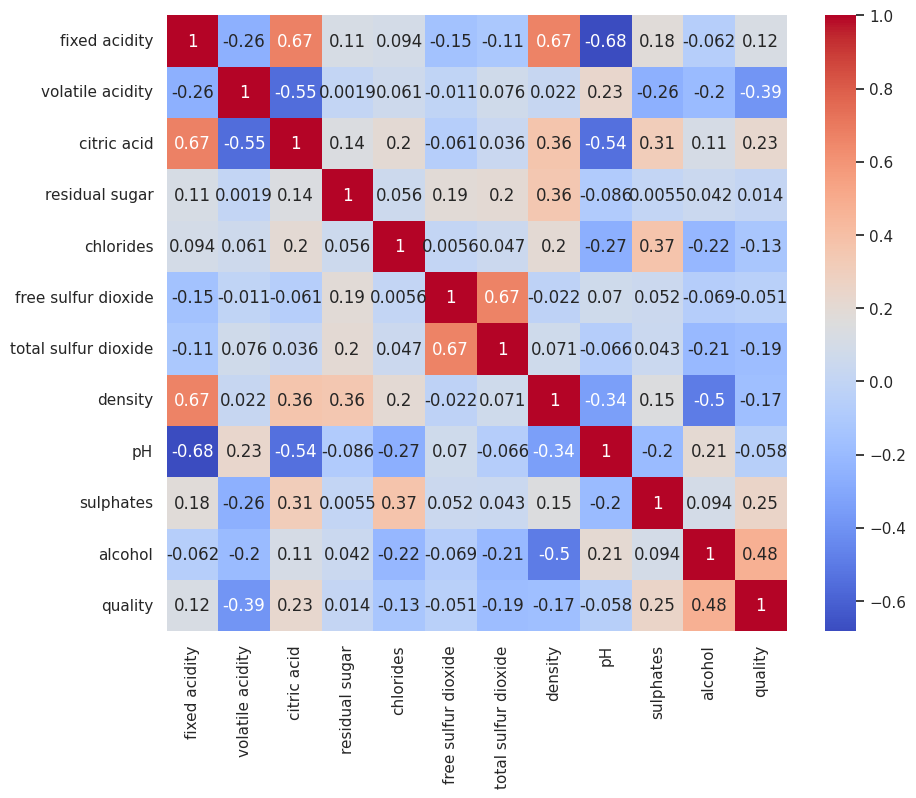

In [ ]:
#heatmap
data=df_red.corr()

plt.figure(figsize=(10,8))
sns.heatmap(data, annot=True, cmap="coolwarm")
plt.show()

In [ ]:
#t-sne


In [ ]:
#worldcloud

In [ ]:
df_red.size

19188

In [ ]:
#PCA reduce the size of attributes to show information in plots
from sklearn.decomposition import PCA
df_red_pca=df_red.copy()

pca = PCA(n_components=2)
pca.fit(df_red_pca)

print(pca.explained_variance_ratio_)
print(pca.singular_values_)

[0.94607951 0.04834835]
[1346.05255997  304.29093596]


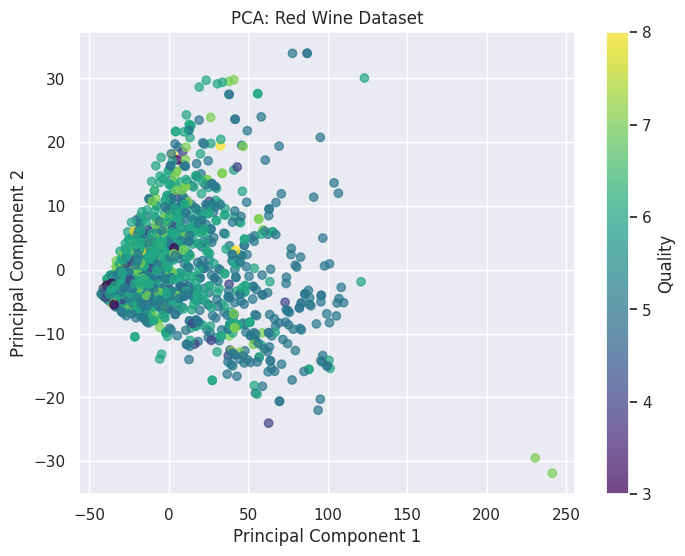

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Применяем PCA для двух компонентов
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_red)

# Создаем график
plt.figure(figsize=(8, 6))

# Визуализируем данные после PCA (первая и вторая компоненты)
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=df_red['quality'], cmap='viridis', alpha=0.7)

# Добавляем подписи осей и заголовок
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: Red Wine Dataset')

# Добавляем цветовую шкалу для качества
plt.colorbar(label='Quality')

# Показываем график
plt.show()


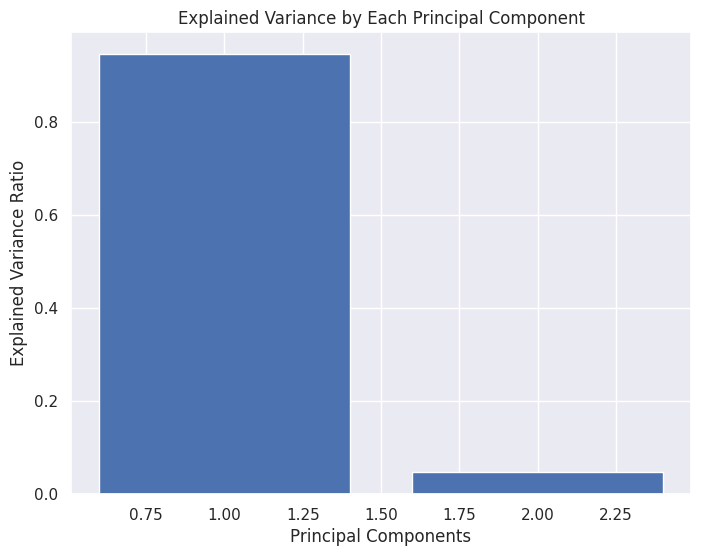

In [ ]:
# График объясненной дисперсии
plt.figure(figsize=(8, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Each Principal Component')
plt.show()


In [ ]:
# Calculate skewness of alcohol distribution
from scipy.stats import skew
print("Skewness of alcohol distribution:", skew(df_red['alcohol']))

Skewness of alcohol distribution: 0.8600210646566755


In [ ]:
skew([-3,-2,-1,0,1,2,3])

np.float64(0.0)

In [ ]:
# Pearson
from scipy.stats import pearsonr

def get_pearson(column1, column2,df):
  pearson_corr,p_value= pearsonr(df[column1],df[column2])


  print(f"Pearson corr {pearson_corr:.2f}")
  print(f"P_value: {p_value:.2f}")

get_pearson("alcohol", "pH", df_red)

Pearson corr 0.21
P_value: 0.00


Analysis of White Wine

In [ ]:
#descreptive
df_white.describe()
display(df_white["quality"].unique())

array([6, 5, 7, 8, 4, 3, 9])

In [ ]:
#Compare quality means between red and white wines
rd=df_red["quality"].mean()
wd=df_white["quality"].mean()
print(f'Red: {rd}')
print(f'White: {wd}')

Red: 5.6360225140712945
White: 5.87790935075541


In [ ]:
#Create a DataFrame

d={
    'color':["red", "white"],
    'score':[df_red["quality"].mean(), df_white["quality"].mean()]
}

da=pd.DataFrame(d)
print(da)

   color     score
0    red  5.636023
1  white  5.877909


In [ ]:
# Create a DataFrame comparing quality means
d={
    'color':["red","white"],
    'score':[df_red["quality"].mean(),df_white["quality"].mean(),]
}

dp=pd.DataFrame(d)
print(dp)


   color     score
0    red  5.636023
1  white  5.877909


In [ ]:
#sort value
uni_quality= df_red["quality"].unique()
uni_quality.sort()
print(uni_quality)

[3 4 5 6 7 8]


In [ ]:
sd=df_red['quality'].value_counts()
sd

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


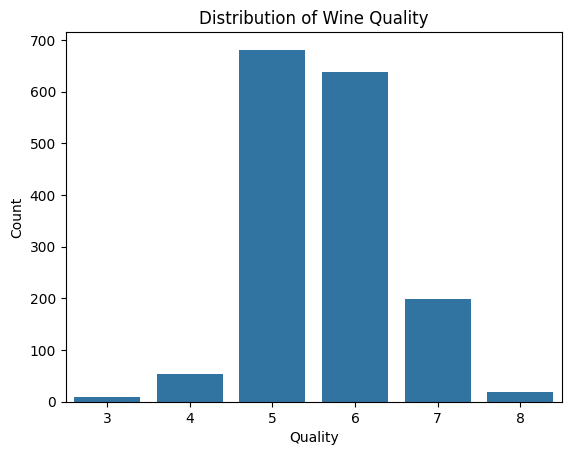

In [ ]:
sns.barplot(x=sd.index, y=sd.values)

# Adding labels and title
plt.xlabel('Quality')
plt.ylabel('Count')
plt.title('Distribution of Wine Quality')

plt.show()

In [ ]:
df_red["quality"].unique()

array([5, 6, 7, 4, 8, 3])

#### Cell 6: Add Wine Category and Create Quality Labels

In [ ]:
df_red['category'] = 'Red'


def category_wine(x):
  if x<=5:
    return"Low"
  if x>=6 and x<=7:
   return "Medium"
  else:
    return "High"


df_red['Label']=df_red["quality"].apply(category_wine)
df_red.head()



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_category,Label,Wine_category,category
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Red,Low,Red,Red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,Red,Low,Red,Red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,Red,Low,Red,Red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,Red,Medium,Red,Red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Red,Low,Red,Red


In [ ]:
df_red.drop("wine_category",axis=1)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Label,Wine_category
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,Low,Red
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,Low,Red
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,Low,Red
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,Medium,Red
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,Low,Red
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,Low,Red
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,Medium,Red
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,Medium,Red
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,Low,Red


In [ ]:
df_white.drop("Wine category", axis=1)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Wine_category,Label
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6,White,High
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6,White,High
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6,White,High
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,White,High
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,White,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,White,High
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,White,Low
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,White,High
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,White,Medium


In [ ]:
df_white["category"]="White"

def add_category(x):
  if x<=5:
    return "Low"
  if 4 <=x and x>=7:
    return "Medium"
  else:
    return "High"


df_white["Label"]=df_white["quality"].apply(add_category)
df_white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Wine category,Wine_category,Label,category
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,White,White,High,White
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,White,White,High,White
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,White,White,High,White
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,White,White,High,White
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,White,White,High,White


In [ ]:
# Merging both dataframes
df_combined = pd.concat([df_red, df_white])

print(df_combined[['category' , 'quality', 'Label']].head(10))

  category  quality   Label
0      Red        5     Low
1      Red        5     Low
2      Red        5     Low
3      Red        6  Medium
4      Red        5     Low
5      Red        5     Low
6      Red        5     Low
7      Red        7  Medium
8      Red        7  Medium
9      Red        5     Low


In [ ]:
print(df_combined['category'].value_counts())


category
White    4898
Red      1599
Name: count, dtype: int64


In [ ]:
df_combined["category"].unique()

array(['Red', 'White'], dtype=object)

In [ ]:
huk=df_combined.groupby('Label')["quality"].mean()
print(huk)

Label
High      6.016245
Low       4.884228
Medium    6.761202
Name: quality, dtype: float64


In [ ]:
er=df_red['Label'].value_counts()
er

,count
Label,
Medium,837
Low,744
High,18


In [ ]:
# Объединяем два датафрейма и сбрасываем индексы
df_wines = pd.concat([df_red, df_white], ignore_index=True)

# Удаляем дублирующиеся столбцы
df_wines = df_wines.drop(columns=['Wine_category', 'category', 'Wine category'], errors='ignore')

# Проверяем, есть ли пропущенные значения
print(df_wines.isnull().sum())

# Выводим обновлённый датафрейм
df_wines.head()


fixed acidity              0
volatile acidity           0
citric acid                0
residual sugar             0
chlorides                  0
free sulfur dioxide        0
total sulfur dioxide       0
density                    0
pH                         0
sulphates                  0
alcohol                    0
quality                    0
wine_category           4898
Label                      0
dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_category,Label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Red,Low
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,Red,Low
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,Red,Low
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,Red,Medium
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Red,Low


In [ ]:
# Combine the two datasets
df_wines = pd.concat([df_red, df_white])

# Re-shuffle records to randomize data points
#df_wines = df_wines.sample(frac=1.0, random_state=42).reset_index(drop=True)
display(df_wines.head(10))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_category,Label,Wine_category,category,Wine category
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Red,Low,Red,Red,NaN
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,Red,Low,Red,Red,NaN
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,Red,Low,Red,Red,NaN
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,Red,Medium,Red,Red,NaN
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Red,Low,Red,Red,NaN
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,Red,Low,Red,Red,NaN
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,Red,Low,Red,Red,NaN
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,Red,Medium,Red,Red,NaN
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,Red,Medium,Red,Red,NaN
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,Red,Low,Red,Red,NaN


In [ ]:
df_red["Label"].count()

np.int64(1599)

### Cell 7: Descriptive Statistics by Wine Quality Category

NameError: name 'pd' is not defined

# Data Preprocessing


## Importing and Slicing

In [ ]:
## Importing Libraries
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
dataset = pd.read_csv('/content/Data.csv')
dataset.size
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    10 non-null     object 
 1   Age        9 non-null      float64
 2   Salary     9 non-null      float64
 3   Purchased  10 non-null     object 
dtypes: float64(2), object(2)
memory usage: 452.0+ bytes


In [ ]:
x=dataset.iloc[: :-1]
x

,Country,Age,Salary,Purchased
9,France,37.0,67000.0,Yes
8,Germany,50.0,83000.0,No
7,France,48.0,79000.0,Yes
6,Spain,NaN,52000.0,No
5,France,35.0,58000.0,Yes
4,Germany,40.0,NaN,Yes
3,Spain,38.0,61000.0,No
2,Germany,30.0,54000.0,No
1,Spain,27.0,48000.0,Yes
0,France,44.0,72000.0,No


## Handling Missing Values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    10 non-null     object 
 1   Age        9 non-null      float64
 2   Salary     9 non-null      float64
 3   Purchased  10 non-null     object 
dtypes: float64(2), object(2)
memory usage: 452.0+ bytes


In [ ]:
dataset.isnull().sum()

,0
Country,0
Age,1
Salary,1
Purchased,0


In [ ]:
dataset.isnull().values.any()

np.True_

In [ ]:
dataset_1=dataset.copy()
dataset_1.isnull().values.any()

np.True_

In [ ]:
dataset_clean=dataset_1.dropna()

In [ ]:
dataset_clean.isnull().sum()
dataset_clean.isnull().values.any()


np.False_

In [ ]:
#missing=["n/a", "na", "--", "NaN", "NA"]
df=pd.read_csv("/content/Data.csv")#, na_values = missing)
df.isnull().sum()

,0
Country,0
Age,1
Salary,1
Purchased,0


In [ ]:
df

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes
5,France,35.0,58000.0,Yes
6,Spain,NaN,52000.0,No
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes


In [ ]:
from sklearn.impute import SimpleImputer
numerical_imputer=SimpleImputer(missing_values=np.nan, strategy="mean")

df_imuted=df.copy()
#df_imuted_c=df.copy()

df_imuted[["Salary","Age"]]=pd.DataFrame(numerical_imputer.fit_transform(df[["Salary","Age"]]))
print("Numerical:\n ", df_imuted)


#categorical_imputer=SimpleImputer(missing_values=np.nan, strategy="most_frequent")

#df_imuted_c[["Country","Purchased"]]=pd.DataFrame(categorical_imputer.fit_transform(df[["Country","Purchased"]]))#columns=df.columns[["Country","Purchased"]]
#print("\nCategorical:\n ", df_imuted_c)


Numerical:
     Country        Age        Salary Purchased
0   France  44.000000  72000.000000        No
1    Spain  27.000000  48000.000000       Yes
2  Germany  30.000000  54000.000000        No
3    Spain  38.000000  61000.000000        No
4  Germany  40.000000  63777.777778       Yes
5   France  35.000000  58000.000000       Yes
6    Spain  38.777778  52000.000000        No
7   France  48.000000  79000.000000       Yes
8  Germany  50.000000  83000.000000        No
9   France  37.000000  67000.000000       Yes


### Encoding categorical

In [ ]:
from sklearn.preprocessing import LabelEncoder
df_imuted
encoder=LabelEncoder()
df_imuted["Purchased"]=encoder.fit_transform(df_imuted["Purchased"])
#encoded_df["Country"]=encoder.fit_transform(df_en["Country"])
#print(encoded_df)

df_imuted["Purchased"]

,Purchased
0,0
1,1
2,0
3,0
4,1
5,1
6,0
7,1
8,0
9,1


In [ ]:
#df_imuted["Country"] = encoder.fit_transform(df_imuted["Country"])

#print(df_imuted["Country"])
df_imuted

,Country,Age,Salary,Purchased
0,France,44.000000,72000.000000,0
1,Spain,27.000000,48000.000000,1
2,Germany,30.000000,54000.000000,0
3,Spain,38.000000,61000.000000,0
4,Germany,40.000000,63777.777778,1
5,France,35.000000,58000.000000,1
6,Spain,38.777778,52000.000000,0
7,France,48.000000,79000.000000,1
8,Germany,50.000000,83000.000000,0
9,France,37.000000,67000.000000,1


### One Hot Encoder


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Определяем трансформации
column_transformer = ColumnTransformer([
    #('num_imputer', SimpleImputer(strategy='mean'), ['Age', 'Salary']),  # Заполняем пропущенные числа средним
    ('cat_encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Country']),
    # OneHotEncoder для 'Country'
], remainder='passthrough')  # Остальные колонки оставляем без изменений

# Применяем трансформации
df_transformed = column_transformer.fit_transform(df)

# Создаем новый DataFrame с обновленными колонками
new_columns =  list(column_transformer.named_transformers_['cat_encoder'].get_feature_names_out(['Country'])) + ['Purchased']
df_final = pd.DataFrame(df_transformed, columns=new_columns)

# Выводим итоговый DataFrame
print(df_final)







TypeError: LabelEncoder.fit_transform() takes 2 positional arguments but 3 were given

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

X = df_final.drop('Salary', axis=1)

y=df_final["Salary"]

XTrain, xTest, yTrain, yTest = train_test_split(X, y, test_size=0.3, random_state=42)

print(XTrain.shape, xTest.shape, yTrain.shape, yTest.shape)
pd.DataFrame(XTrain)


(7, 5) (3, 5) (7,) (3,)


,Age,Country_France,Country_Germany,Country_Spain,Purchased
0,44.0,1.0,0.0,0.0,No
7,48.0,1.0,0.0,0.0,Yes
2,30.0,0.0,1.0,0.0,No
9,37.0,1.0,0.0,0.0,Yes
4,40.0,0.0,1.0,0.0,Yes
3,38.0,0.0,0.0,1.0,No
6,38.777778,0.0,0.0,1.0,No


Splitting



In [ ]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

x, y = make_blobs(n_samples=1000)
pd.DataFrame(x)

xTrain, xTest, yTrain, yTest = train_test_split(x, y, test_size=0.3, random_state=42)


print(xTrain.shape, xTest.shape, yTrain.shape, yTest.shape)
pd.DataFrame(xTrain)


(700, 2) (300, 2) (700,) (300,)


,0,1
0,1.650152,-0.845640
1,12.510736,7.299060
2,1.768573,-1.063330
3,2.116618,-8.113360
4,0.864605,-1.214353
...,...,...
695,3.158615,-2.692054
696,1.735615,-2.057977
697,8.333660,4.128150
698,2.737328,-2.221859


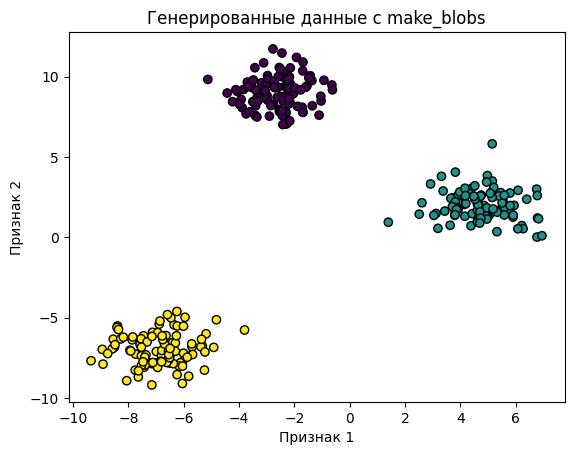

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Создаем данные с 3 кластерами
X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

# Визуализируем данные

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.title("Генерированные данные с make_blobs")
plt.show()


In [ ]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=10, centers=3, n_features=2,
                  random_state=0)

print(X.shape)




(10, 2)


In [ ]:
y

array([0, 0, 1, 0, 2, 2, 2, 1, 1, 0])

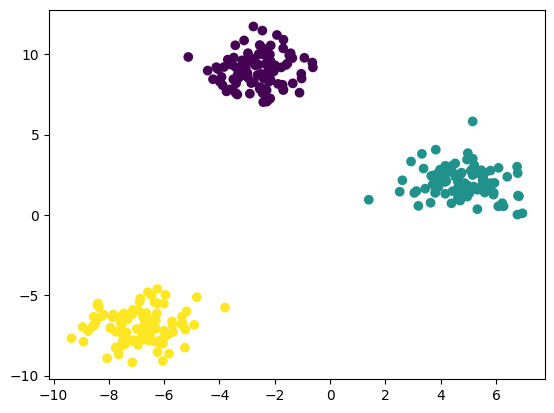

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', marker='o')
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.datasets import make_blobs


X, y = make_blobs(n_samples=10, centers=3, n_features=2,
                  random_state=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)


print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
pd.DataFrame(X_train).head()

(201, 2) (99, 2) (201,) (99,)


,0,1
0,-6.168012,-8.004752
1,4.324610,2.732139
2,-3.571501,9.487879
3,-3.580090,9.496759
4,6.272290,0.543028


In [90]:
#correct data preprossesing
dataset = pd.read_csv("/content/Data.csv")
dataset

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes
5,France,35.0,58000.0,Yes
6,Spain,NaN,52000.0,No
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes


In [91]:
import numpy as np
from sklearn.impute import SimpleImputer
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')

imputed_data=imp_mean.fit_transform(dataset[["Salary","Age"]])
imputed_datas=pd.DataFrame(imputed_data, columns=["Salary","Age"])
imputed_datas.isnull()

,Salary,Age
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
5,False,False
6,False,False
7,False,False
8,False,False
9,False,False


In [92]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data_labeled=le.fit_transform(dataset["Purchased"])
datas_labeled=pd.DataFrame(data_labeled, columns=["Purchased"])
datas_labeled



,Purchased
0,0
1,1
2,0
3,0
4,1
5,1
6,0
7,1
8,0
9,1


In [106]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

data_enc=enc.fit_transform(dataset[["Country"]])
datas_enc=pd.DataFrame(data_enc,columns=["Germany","Spain", "France"])
datas_enc


,Germany,Spain,France
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,0.0,1.0,0.0
3,0.0,0.0,1.0
4,0.0,1.0,0.0
5,1.0,0.0,0.0
6,0.0,0.0,1.0
7,1.0,0.0,0.0
8,0.0,1.0,0.0
9,1.0,0.0,0.0


In [94]:
import pandas as pd

# Объединяем все три DataFrame по столбцам
data_con = pd.concat([datas_enc, datas_labeled, imputed_datas], axis=1)

# Выводим результат
data_con.head()


,Germany,Spain,France,Purchased,Salary,Age
0,1.0,0.0,0.0,0,72000.000000,44.0
1,0.0,0.0,1.0,1,48000.000000,27.0
2,0.0,1.0,0.0,0,54000.000000,30.0
3,0.0,0.0,1.0,0,61000.000000,38.0
4,0.0,1.0,0.0,1,63777.777778,40.0


In [95]:
data_con["Salary"].isnull()

,Salary
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [ ]:
#x = dataset.iloc[:, :-1]  # All columns except the last one
#y = dataset.iloc[:, -1]

In [96]:
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd


x = data_con.drop("Salary",axis=1)
y = data_con["Salary"]

xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, test_size=0.33, random_state=42) #stratify=y

print(xtrain.shape, xtest.shape, ytrain.shape, ytest.shape)
pd.DataFrame(xtrain)


(6, 5) (4, 5) (6,) (4,)


,Germany,Spain,France,Purchased,Age
7,1.0,0.0,0.0,1,48.000000
2,0.0,1.0,0.0,0,30.000000
9,1.0,0.0,0.0,1,37.000000
4,0.0,1.0,0.0,1,40.000000
3,0.0,0.0,1.0,0,38.000000
6,0.0,0.0,1.0,0,38.777778


In [97]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import pandas as pd

MinMax=MinMaxScaler()
standart= StandardScaler()

m_xtrain=xtrain.copy()
s_xtrain=xtrain.copy()


mscaler_xtrain=MinMax.fit_transform(m_xtrain)
sscaler_xtrain=standart.fit_transform(s_xtrain)

mscaler_xtrain=pd.DataFrame(mscaler_xtrain, columns=["Germany",	"Spain", "France",	"Purchased",	"Age"])
sscaler_xtrain=pd.DataFrame(sscaler_xtrain, columns=["Germany",	"Spain", "France",	"Purchased",	"Age"])


display(mscaler_xtrain)
display(sscaler_xtrain)

,Germany,Spain,France,Purchased,Age
0,1.0,0.0,0.0,1.0,1.000000
1,0.0,1.0,0.0,0.0,0.000000
2,1.0,0.0,0.0,1.0,0.388889
3,0.0,1.0,0.0,1.0,0.555556
4,0.0,0.0,1.0,0.0,0.444444
5,0.0,0.0,1.0,0.0,0.487654


,Germany,Spain,France,Purchased,Age
0,1.414214,-0.707107,-0.707107,1.0,1.774925
1,-0.707107,1.414214,-0.707107,-1.0,-1.634615
2,1.414214,-0.707107,-0.707107,1.0,-0.308683
3,-0.707107,1.414214,-0.707107,1.0,0.259574
4,-0.707107,-0.707107,1.414214,-1.0,-0.119264
5,-0.707107,-0.707107,1.414214,-1.0,0.028062


In [103]:
from sklearn.decomposition import PCA


psa_xtrain=sscaler_xtrain.copy() #new copied data

pca = PCA(n_components=2)
df_pca =pca.fit_transform(psa_xtrain)

print(pca.explained_variance_ratio_)
print(pca.singular_values_)


df_pcaa = pd.DataFrame(df_pca, columns=["PC1", "PC2"])

print(df_pcaa)



[0.52412943 0.34707548]
[3.96533514 3.22680404]
        PC1       PC2
0  2.539418 -0.593086
1 -1.697015  1.805139
2  1.614223  0.105841
3  0.269198  1.595501
4 -1.395621 -1.431988
5 -1.330203 -1.481407


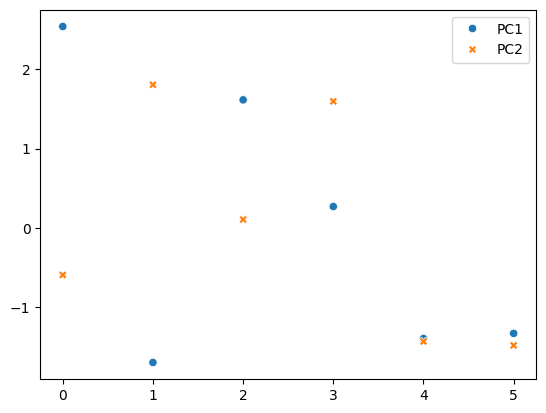

In [104]:
# grph of PSA

from matplotlib.pyplot import scatter
import numpy as np
import matplotlib.pyplot as plt

sns.scatterplot(data=df_pcaa)
plt.show()


In [105]:
principalDf = pd.concat([df_pcaa, data_con[['Salary']]], axis = 1)
principalDf

,PC1,PC2,Salary
0,2.539418,-0.593086,72000.000000
1,-1.697015,1.805139,48000.000000
2,1.614223,0.105841,54000.000000
3,0.269198,1.595501,61000.000000
4,-1.395621,-1.431988,63777.777778
5,-1.330203,-1.481407,58000.000000
6,NaN,NaN,52000.000000
7,NaN,NaN,79000.000000
8,NaN,NaN,83000.000000
9,NaN,NaN,67000.000000


### Scaling


#### Normalization

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler


In [ ]:
minmax=MinMaxScaler()
standard=StandardScaler()
dt=data_con.copy()
st_dt=data_con.copy()

In [ ]:
#AGE SAlary minmax

minmax_d=minmax.fit_transform(dt[["Age","Salary"]])
pd.DataFrame(minmax_d)

,0,1
0,0.739130,0.685714
1,0.000000,0.000000
2,0.130435,0.171429
3,0.478261,0.371429
4,0.565217,0.450794
5,0.347826,0.285714
6,0.512077,0.114286
7,0.913043,0.885714
8,1.000000,1.000000
9,0.434783,0.542857


In [ ]:
#AGE SAlary standart
standard_d=standard.fit_transform(st_dt[["Age","Salary"]])
pd.DataFrame(standard_d)

,0,1
0,0.758874,7.494733e-01
1,-1.711504,-1.438178e+00
2,-1.275555,-8.912655e-01
3,-0.113024,-2.532004e-01
4,0.177609,6.632192e-16
5,-0.548973,-5.266569e-01
6,0.000000,-1.073570e+00
7,1.340140,1.387538e+00
8,1.630773,1.752147e+00
9,-0.258340,2.937125e-01


PCA (Principal Component Analysis) — это Метод главных компонент, используемый для снижения размерности данных.



Что делает PCA?

🔹 Преобразует исходные признаки в новые компоненты (главные компоненты).

🔹 Компоненты упорядочены по важности (первая компонента объясняет больше дисперсии, чем вторая и т. д.).

🔹 Позволяет уменьшить число признаков, сохраняя максимальную информацию.



In [ ]:
import numpy as np
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca =pca.fit_transform(standard_d)

print(pca.explained_variance_ratio_)
print(pca.singular_values_)
df_pca

df_pcaa = pd.DataFrame(df_pca, columns=["PC1", "PC2"])

print(df_pcaa)

[0.95628854 0.04371146]
[4.37330204 0.93500227]
        PC1       PC2
0  1.066563  0.006648
1 -2.227162 -0.193270
2 -1.532173 -0.271734
3 -0.258960  0.099120
4  0.125588  0.125588
5 -0.760585 -0.015780
6 -0.759128  0.759128
7  1.928760 -0.033516
8  2.392085 -0.085825
9  0.025012 -0.390360


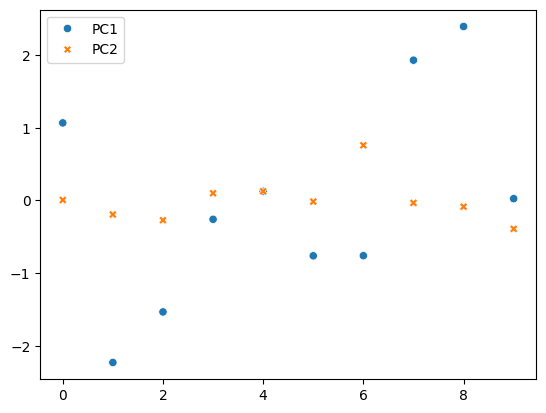

In [ ]:
from matplotlib.pyplot import scatter
import numpy as np
import matplotlib.pyplot as plt

sns.scatterplot(data=df_pcaa)
plt.show()


### Feature Engineering

Nominal data (номинальные данные) — это тип категориальных данных, которые представляют собой отдельные, неупорядоченные категории или группы. Эти данные не имеют числового значения и не могут быть логически упорядочены

need to convert numeric

In [111]:
df_redd = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv", delimiter=";")
df_whitee = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv", delimiter=";")
dm = pd.read_csv("https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv")

# Display the first few rows to verify data loading
print("Red Wine Dataset (first 5 rows):")
display(df_redd.head(2))

print("White Wine Dataset (first 5 rows):")
display(df_whitee.head(2))
# Display raws in pima-Indians-Diabetes-Dataset
display(dm.head(2))


Red Wine Dataset (first 5 rows):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5


White Wine Dataset (first 5 rows):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.001,3.0,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.994,3.3,0.49,9.5,6


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0


In [118]:
# specific columns to introduce NaN values
selected_columns = ['citric acid', 'pH']

# Introduce NaN values randomly in selected columns
np.random.seed(42)
for col in selected_columns:
    mask = np.random.rand(df_whitee.shape[0]) < 0.01
    df_whitee.loc[mask, col] = np.nan

In [119]:
print("For White\n")
display(df_whitee.isnull().any())
print("\nFor Red\n")
display(df_redd.isnull().any())

For White



,0
fixed acidity,False
volatile acidity,False
citric acid,True
residual sugar,False
chlorides,False
free sulfur dioxide,False
total sulfur dioxide,False
density,False
pH,True
sulphates,False



For Red



,0
fixed acidity,False
volatile acidity,False
citric acid,False
residual sugar,False
chlorides,False
free sulfur dioxide,False
total sulfur dioxide,False
density,False
pH,False
sulphates,False


### Feature engineering techniques in Python

In [122]:
# Mean imputation
df_mean = df_whitee.copy()
df_mean.fillna(df_mean.mean(), inplace=True)
df_mean.isnull().any()

,0
fixed acidity,False
volatile acidity,False
citric acid,False
residual sugar,False
chlorides,False
free sulfur dioxide,False
total sulfur dioxide,False
density,False
pH,False
sulphates,False


In [123]:
# Forward Fill
df_ffill = df_whitee.copy()
df_ffill.fillna(method='ffill', inplace=True)

# Forward Fill
df_bfill = df_whitee.copy()
df_bfill.fillna(method='bfill', inplace=True)


### Feature selection
Filter Methods (correlation coefficients, chi-square tests, and mutual information)

Wrapper Methods (recursive feature elimination (RFE) and forward/backward feature selection)

Feature Importance from Tree-based Models


In [ ]:


def correlation_feature_selection(df, threshold=0.1):

    # Compute correlation matrix
    corr_matrix = df.corr()#.abs()

    # Create mask for upper triangle to avoid duplicate checks
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Identify columns to drop
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    # Drop correlated features
    return df.drop(columns=to_drop)

# Copy the original DataFrame
df_select = df_white.copy()

# Apply correlation feature selection
df_selected = correlation_feature_selection(df_select, threshold=0.1)

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df_selected.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Feature Correlation Matrix After Selection")
plt.show()

# Display remaining features as a table
print("selected features:")
display(df_selected.head()) #.describe())#.T)


In [ ]:

def chi_square_feature_selection(X, y, k=5):

    chi2_selector = SelectKBest(chi2, k=k)
    X_new = chi2_selector.fit_transform(X, y)
    selected_features = X.columns[chi2_selector.get_support()]
    scores = chi2_selector.scores_[chi2_selector.get_support()]
    feature_scores = pd.DataFrame({'Feature': selected_features, 'Chi2 Score': scores})
    feature_scores = feature_scores.sort_values(by='Chi2 Score', ascending=True)
    return X[selected_features], feature_scores

# dataset with out NULL records
df_select_chi= df_bfill.copy()

# Assuming 'quality' is the dependent variable in our data set
y = df_select_chi['quality']
X = df_select_chi.drop(columns=['quality'])

# Apply Chi-Square feature selection to select the best 5 features
df_selected, feature_scores = chi_square_feature_selection(X, y, k=5)

# Display remaining features as a table
print("Selected features:")
display(df_selected.head())

# Bar plot of selected features sorted by Chi2 score
plt.figure(figsize=(8, 6))
sns.barplot(x='Chi2 Score', y='Feature', data=feature_scores, palette='viridis')
plt.xlabel("Chi2 Score")
plt.ylabel("Feature")
plt.title("Top 5 Features Selected by Chi-Square Test")
plt.show()




In [ ]:
# Assuming 'quality' is your target variable and we handled missing values
df_rfe = df_bfill.copy()
y = df_rfe['quality']
X = df_rfe.drop(columns=['quality'])

# Initialize the Logistic Regression model, but you can use other models as well
model = LogisticRegression()

# Initialize RFE with the model and the desired number of features
rfe = RFE(estimator=model, n_features_to_select=5) # Select top 5 features

# Fit RFE to the data
rfe.fit(X, y)

# Get the selected features
selected_features = X.columns[rfe.support_]

# Get the ranking of all features
feature_ranking = pd.DataFrame({'Feature': X.columns, 'Ranking': rfe.ranking_})

# Print the selected features
print("Selected Features:")
print(selected_features)

# Display feature rankings
print("\nFeature Ranking:")
print(feature_ranking)

# Create a new DataFrame with only the selected features
df_selected_rfe = df_rfe[selected_features]

# Example: Display the first few rows of the new DataFrame
print("\nDataFrame with Selected Features:")
display(df_selected_rfe.head())


In [ ]:
# Suppse 'quality' is your target variable
df_tree = df_bfill.copy()
y = df_tree['quality']
X = df_tree.drop(columns=['quality'])

# Initialize a RandomForestClassifier here, but you can use another tree-based model
model = RandomForestClassifier()

# Fit the model to your data
model.fit(X, y)
importances = model.feature_importances_

# Create a DataFrame to display feature importances
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

# Sort the DataFrame by importance
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Display the feature importances
print("\nFeature Importances:")
display(feature_importances)

# You can also plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances using Random Forest')
plt.show()


#### Dealing with imbalanced datasets (diabetes)

In [ ]:
# diabetes dataset (which has imbalanced data)
df.head()

In [ ]:

x=df.drop(["Outcome"],axis=1)
y=df["Outcome"]
count_class = y.value_counts() # Count the occurrences of each class
plt.bar(count_class.index, count_class.values)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title("Class Distribution Before SMOTE")
plt.xticks(count_class.index, ['Class 0', 'Class 1'])
plt.show()


In [ ]:

# Apply SMOTE
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_resampled, y_resampled = smote.fit_resample(x, y)

# Check class distribution after SMOTE
sns.countplot(x=y_resampled, palette="coolwarm")
plt.title("Class Distribution After SMOTE")
plt.xlabel("Outcome")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# Print the updated class counts
print("Class distribution before SMOTE:\n", y.value_counts())
print("\nClass distribution after SMOTE:\n", y_resampled.value_counts())


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y)
# Train a Random Forest classifier on the imbalanced dataset
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
# Predict on the test set
y_pred = clf.predict(X_test)
# Evaluate the model
print("Classification Report (Before SMOTE):")
print(classification_report(y_test, y_pred))

In [ ]:
# Train the classifier on the SMOTE-balanced dataset
clf_smote = RandomForestClassifier(random_state=48)
clf_smote.fit(X_resampled, y_resampled)
# Predict on the test set
y_pred_smote = clf_smote.predict(X_test)
# Evaluate the model
print("Classification Report (After SMOTE):")
print(classification_report(y_test, y_pred_smote))